<a href="https://colab.research.google.com/github/panithan1991/Exploring-Thailand-s-Government-Procurement-Spending/blob/main/notebook/05_construction_storytelling_visuals_2569.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


> **ผลลัพธ์ตัวอย่าง:** กราฟและตารางที่ฝังใน Notebook มาจากการรันต้นฉบับที่ผู้จัดทำส่งมา ผลเมื่อรันใหม่ขึ้นอยู่กับรุ่นของ CSV ที่ใช้


## วิธีรันเวอร์ชัน GitHub

เปิด Notebook ใน Google Colab แล้วเลือก **Runtime → Run all**; ระบบดาวน์โหลด CSV ที่ต้องใช้จาก [data_for_github](https://drive.google.com/drive/folders/1ssVrUcY4TiYee9T2B0pwgr5SwvPp_lAq) ลงพื้นที่ชั่วคราว ไม่ต้อง Mount Drive ส่วนตัวหรือรัน Notebook 02–04 ก่อน

- กราฟและตารางแสดงใน Notebook **ไม่บันทึก PNG, SVG หรือ CSV** ไปยัง Drive ของผู้อ่าน
- หากดาวน์โหลดจาก Drive ไม่ได้ ให้ดาวน์โหลด CSV ทั้งห้าไฟล์เอง แล้วกำหนด `LOCAL_DATA_DIR` ในเซลล์ตั้งค่า
- เซลล์สุดท้ายลบไฟล์พักและปิดรูป แต่เก็บ DataFrame ผลวิเคราะห์ไว้ให้ตรวจย้อนกลับได้
- หาก RAM ใช้ถึง 80% โค้ดจะหยุดก่อนอ่านหรือประมวลผลขั้นใหญ่ เพื่อไม่ให้ Runtime ใช้ swap หนัก
- โค้ดเกณฑ์และกราฟใช้สูตรจากไฟล์ `05_construction_storytelling_visuals_2569_updated.ipynb` ไม่แก้จำนวนเพื่อให้ตรงกับผลลัพธ์เดิม


In [1]:
# GitHub / Colab: ดาวน์โหลดข้อมูลเฉพาะที่ใช้ลงพื้นที่ชั่วคราว ไม่ต้อง Mount Drive
# เปลี่ยนเป็น Path โฟลเดอร์ข้อมูลที่มีอยู่แล้วได้ เพื่อไม่ต้องดาวน์โหลดซ้ำ
LOCAL_DATA_DIR = None
import atexit
import gc
import hashlib
import importlib.util
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path

# ติดตั้งเฉพาะแพ็กเกจที่ยังไม่มี; subprocess นี้รอจนจบ ไม่มี worker ค้าง
_packages = {"pandas": "pandas>=2.2,<3", "numpy": "numpy", "matplotlib": "matplotlib", "psutil": "psutil", "gdown": "gdown", "IPython": "ipython"}
_missing_packages = [requirement for module, requirement in _packages.items() if importlib.util.find_spec(module) is None]
if _missing_packages:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_missing_packages], check=True)
import psutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gdown
from IPython.display import display

def check_memory(stage="ประมวลผล"):
    # หยุดอย่างชัดเจนเมื่อ RAM สูง แทนการฝืนจน Runtime หลุด
    if psutil.virtual_memory().percent >= 80:
        gc.collect()
        if psutil.virtual_memory().percent >= 80:
            raise MemoryError(f"RAM ใช้เกิน 80% ก่อน {stage}; กรุณา Restart runtime หรือใช้ High-RAM แล้ว Run all ใหม่")

# รัน setup ซ้ำจะปิดพื้นที่ชั่วคราวของ Notebook รอบก่อน
if "_github_runtime" in globals():
    _github_runtime.cleanup()
_github_runtime = tempfile.TemporaryDirectory(prefix="procurement_github_")
atexit.register(_github_runtime.cleanup)
RUNTIME_DIR = Path(_github_runtime.name)
DATA_DIR = RUNTIME_DIR / "inputs"
DATA_DIR.mkdir()
_initial_figure_numbers = set(plt.get_fignums())

DATA_FILES = {
    "construction_contract_supplier_study_scope_2569.csv": {
        "id": "1dXH9N4ukZAabRQwl9nkQ-KidB1e80ZAh",
        "size": 243311179
    },
    "construction_contract_review_indicators_2569.csv": {
        "id": "1nYgjub4kfLTyX_9gnz3dM2GZWUM67wRJ",
        "size": 247613515
    },
    "repeated_near_500k_agency_supplier_2569.csv": {
        "id": "10fT6PqZbBa5mS4GEHHEOf8_qIeASToQk",
        "size": 364037
    },
    "agency_supplier_dependence_2569.csv": {
        "id": "1IcOigDI8HdPjC2JqnYiNbQz1_6S23qxl",
        "size": 19133
    },
    "priority_review_contracts_2569.csv": {
        "id": "1prDQwSgkNCFqarTx0rkFuQK12Q5J2MT_",
        "size": 108598
    }
}

def data_file(name):
    # ใช้ไฟล์ในเครื่องก่อนถ้าผู้ใช้ระบุโฟลเดอร์ โดยไม่แก้ไขไฟล์ต้นฉบับ
    if LOCAL_DATA_DIR is not None:
        candidate = Path(LOCAL_DATA_DIR) / name
        if candidate.is_file():
            return candidate
    if name not in DATA_FILES:
        raise FileNotFoundError(f"ยังไม่มีข้อมูล {name} ในชุดที่แชร์ กรุณาตรวจ DATA_FILES หรือ LOCAL_DATA_DIR")
    item = DATA_FILES[name]
    target = DATA_DIR / name
    if target.is_file():
        return target
    required_bytes = int(item["size"])
    if shutil.disk_usage(DATA_DIR).free < required_bytes + 512 * 1024**2:
        raise OSError(f"พื้นที่ชั่วคราวไม่พอสำหรับ {name}")
    partial = target.with_suffix(target.suffix + ".part")
    print(f"อ่านข้อมูล {name} ({required_bytes / 1024**2:,.1f} MB)")
    try:
        result = gdown.download(id=item["id"], output=str(partial), quiet=False)
        if result is None or not partial.is_file() or partial.stat().st_size != required_bytes:
            raise IOError(f"ดาวน์โหลด {name} ไม่ครบ หรือไฟล์ใน Drive เปลี่ยนรุ่น")
        if item.get("md5"):
            digest = hashlib.md5()
            with partial.open("rb") as stream:
                for block in iter(lambda: stream.read(4 * 1024**2), b""):
                    digest.update(block)
            if digest.hexdigest() != item["md5"]:
                raise IOError(f"Checksum ไม่ตรงสำหรับ {name}")
        partial.replace(target)
    except Exception as exc:
        partial.unlink(missing_ok=True)
        raise RuntimeError(f"อ่าน {name} ไม่สำเร็จ: ตรวจสิทธิ์ Anyone with the link ของโฟลเดอร์ข้อมูล หรือดาวน์โหลดเองแล้วกำหนด LOCAL_DATA_DIR") from exc
    return target

def release_download(path):
    # ลบเฉพาะสำเนาที่ Notebook นี้ดาวน์โหลด ไม่ลบไฟล์ใน LOCAL_DATA_DIR
    path = Path(path)
    if path.parent == DATA_DIR:
        path.unlink(missing_ok=True)

def cleanup_runtime():
    # เก็บ DataFrame ผลวิเคราะห์ไว้ให้ย้อนกลับมาดูต่อได้
    for number in set(plt.get_fignums()) - _initial_figure_numbers:
        plt.close(number)
    _github_runtime.cleanup()
    gc.collect()
    print("ปิดรูปและลบไฟล์พักของ Notebook แล้ว; DataFrame ผลวิเคราะห์ยังอยู่ใน RAM")

check_memory("เริ่ม Notebook")



# จากข้อมูล e-GP 3.96 ล้านระเบียน สู่ 161 สัญญาที่ควรเปิดเอกสารก่อน

Notebook นี้ไม่ได้เริ่มจากการตั้งข้อสงสัย แต่เริ่มจากการสำรวจว่าเรามีข้อมูลอะไร แล้วค่อยลดขอบเขตตามสิ่งที่พบในข้อมูลจริง

เรื่องจะเดินไปตามลำดับนี้:

1. เตรียมข้อมูลจาก e-GP ให้อยู่ในระดับสัญญา
2. มองภาพรวมวงเงินและวิธีจัดซื้อของสัญญาก่อสร้าง
3. ขยายดูบริเวณ 500,000 บาท หลังเห็นการกระจุกตัวจากภาพรวม
4. กำหนดขอบเขตศึกษาที่สอดคล้องกับสิ่งที่พบ
5. มอง Pattern 1 และ Pattern 2 แยกกัน
6. ใช้จุดตัดของสอง Pattern จัดลำดับสัญญาที่ควรเปิดเอกสารก่อน

ผลลัพธ์ทั้งหมดเป็นเพียงสัญญาณสำหรับตรวจสอบต่อ ไม่ใช่หลักฐานการทุจริตหรือการแบ่งซื้อแบ่งจ้าง


In [2]:
from pathlib import Path
from textwrap import shorten

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from matplotlib.patches import (
    Rectangle,
    FancyBboxPatch,
    FancyArrowPatch
)
from IPython.display import HTML, display


def display_table(data):
    html = data.to_html(
        index=False,
        border=0,
        classes='dataframe'
    )
    display(HTML(html))


# ดาวน์โหลดฟอนต์ภาษาไทยลงพื้นที่ชั่วคราวของ Runtime เท่านั้น
import urllib.request
_font_file = RUNTIME_DIR / 'thsarabunnew-webfont.ttf'
urllib.request.urlretrieve('https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf', _font_file)
fm.fontManager.addfont(str(_font_file))

pd.set_option(
    'display.max_columns',
    None
)
pd.set_option(
    'display.max_colwidth',
    100
)
pd.set_option(
    'display.float_format',
    lambda value: f'{value:,.2f}'
)

## เตรียมข้อมูลสำหรับเล่าเรื่อง

Notebook นี้อ่านผลลัพธ์ที่เตรียมและสร้าง flag ไว้แล้วจาก Notebook 02–04 เพื่อให้ภาพทุกภาพใช้นิยามเดียวกัน หากไฟล์ผลลัพธ์ยังไม่ครบ ให้ Run all ตามลำดับ 02 → 03 → 04 ก่อนกลับมารัน Notebook นี้


In [3]:
# ใช้สำเนาข้อมูลที่แชร์สำหรับ GitHub หรือโฟลเดอร์ที่ผู้รันกำหนด
processed_dir = DATA_DIR

contract_path = data_file('construction_contract_supplier_study_scope_2569.csv')
flags_path = data_file('construction_contract_review_indicators_2569.csv')
repeated_pairs_path = data_file('repeated_near_500k_agency_supplier_2569.csv')
dependence_path = data_file('agency_supplier_dependence_2569.csv')
priority_path = data_file('priority_review_contracts_2569.csv')

required_paths = [
    contract_path,
    flags_path,
    repeated_pairs_path,
    dependence_path,
    priority_path
]

missing_paths = [path for path in required_paths if not path.exists()]

if missing_paths:
    missing_text = '\n'.join(str(path) for path in missing_paths)
    raise FileNotFoundError(
        'ไม่พบไฟล์ข้อมูลที่ต้องใช้ กรุณาตรวจลิงก์ Drive หรือ LOCAL_DATA_DIR:\n'
        f'{missing_text}'
    )

check_memory('อ่านข้อมูลสัญญาก่อสร้าง')
contract_data = pd.read_csv(contract_path, low_memory=False)
release_download(contract_path)
check_memory('อ่านข้อมูล flag')
contract_flags = pd.read_csv(flags_path, low_memory=False)
release_download(flags_path)
check_memory('อ่านคู่ที่เข้า Pattern 1')
repeated_pairs = pd.read_csv(repeated_pairs_path, low_memory=False)
release_download(repeated_pairs_path)
check_memory('อ่านคู่ที่เข้า Pattern 2')
pattern2_pairs = pd.read_csv(dependence_path, low_memory=False)
release_download(dependence_path)
check_memory('อ่านรายการตรวจสอบลำดับแรก')
priority_contracts = pd.read_csv(priority_path, low_memory=False)
release_download(priority_path)

file_summary = pd.DataFrame({
    'ข้อมูล': [
        'รายการสัญญา–ผู้รับจ้างก่อสร้าง',
        'รายการพร้อม flag',
        'คู่ที่เข้า Pattern 1',
        'คู่ที่เข้า Pattern 2',
        'รายการตรวจสอบลำดับแรก'
    ],
    'จำนวนแถว': [
        len(contract_data),
        len(contract_flags),
        len(repeated_pairs),
        len(pattern2_pairs),
        len(priority_contracts)
    ]
})

display_table(file_summary)


อ่านข้อมูล construction_contract_supplier_study_scope_2569.csv (232.0 MB)


Downloading...
From (original): https://drive.google.com/uc?id=1dXH9N4ukZAabRQwl9nkQ-KidB1e80ZAh
From (redirected): https://drive.google.com/uc?id=1dXH9N4ukZAabRQwl9nkQ-KidB1e80ZAh&confirm=t&uuid=4e0b9e7e-8774-4ff1-80f4-41d6a7eab007
To: /tmp/procurement_github_bjpp3kyo/inputs/construction_contract_supplier_study_scope_2569.csv.part
100%|██████████| 243M/243M [00:04<00:00, 53.1MB/s]


อ่านข้อมูล construction_contract_review_indicators_2569.csv (236.1 MB)


Downloading...
From (original): https://drive.google.com/uc?id=1nYgjub4kfLTyX_9gnz3dM2GZWUM67wRJ
From (redirected): https://drive.google.com/uc?id=1nYgjub4kfLTyX_9gnz3dM2GZWUM67wRJ&confirm=t&uuid=7f3d9073-a7f3-49f8-835f-d952415c2470
To: /tmp/procurement_github_bjpp3kyo/inputs/construction_contract_review_indicators_2569.csv.part
100%|██████████| 248M/248M [00:02<00:00, 90.4MB/s]


อ่านข้อมูล repeated_near_500k_agency_supplier_2569.csv (0.3 MB)


...

อ่านข้อมูล agency_supplier_dependence_2569.csv (0.0 MB)


Downloading...
From: https://drive.google.com/uc?id=1IcOigDI8HdPjC2JqnYiNbQz1_6S23qxl
To: /tmp/procurement_github_bjpp3kyo/inputs/agency_supplier_dependence_2569.csv.part
100%|██████████| 19.1k/19.1k [00:00<00:00, 13.8MB/s]


อ่านข้อมูล priority_review_contracts_2569.csv (0.1 MB)


Downloading...
From: https://drive.google.com/uc?id=1prDQwSgkNCFqarTx0rkFuQK12Q5J2MT_
To: /tmp/procurement_github_bjpp3kyo/inputs/priority_review_contracts_2569.csv.part
100%|██████████| 109k/109k [00:00<00:00, 64.1MB/s]


ข้อมูล,จำนวนแถว
รายการสัญญา–ผู้รับจ้างก่อสร้าง,179716
รายการพร้อม flag,179716
คู่ที่เข้า Pattern 1,1580
คู่ที่เข้า Pattern 2,79
รายการตรวจสอบลำดับแรก,161


In [4]:
check_memory('สร้างตารางในขอบเขตศึกษา')
project_id_column = 'รหัสโครงการ'
contract_column = 'เลขที่สัญญา'
contract_value_column = 'วงเงินงบประมาณในสัญญา (บาท)'
method_column = 'ชื่อวิธีการจัดซื้อจัดจ้าง'
agency_column = 'ชื่อหน่วยงาน'
province_column = 'จังหวัด'
supplier_id_column = 'เลขประจำตัวนิติบุคคล 13 หลัก'
supplier_name_column = 'ชื่อผู้ชนะการเสนอราคา'
scope_column = 'อยู่ในขอบเขตตรวจรูปแบบ'

flag_columns = [
    'flag_pattern_1',
    'flag_pattern_2',
    'priority_review'
]

for column in flag_columns:
    contract_flags[column] = (
        contract_flags[column]
        .astype('boolean')
        .fillna(False)
    )

study_data = contract_data.loc[contract_data[scope_column]].copy()
near_ceiling_data = study_data.loc[
    study_data[contract_value_column].between(490000, 500000)
].copy()

print(f'รายการสัญญาก่อสร้างทั้งหมด: {len(contract_data):,}')
print(f'รายการในขอบเขตศึกษา: {len(study_data):,}')
print(f'รายการใกล้เพดาน: {len(near_ceiling_data):,}')
print(f'รายการตรวจสอบลำดับแรก: {len(priority_contracts):,}')


รายการสัญญาก่อสร้างทั้งหมด: 179,716
รายการในขอบเขตศึกษา: 136,122
รายการใกล้เพดาน: 20,200
รายการตรวจสอบลำดับแรก: 161


## ภาษาภาพที่ใช้ร่วมกัน

ทุกภาพใช้สีชุดเดียวกันเพื่อให้ตามเรื่องได้ง่าย:

- น้ำเงิน แทนข้อมูลหลัก
- ส้ม แทนบริเวณหรือเงื่อนไขที่กำลังสนใจ
- แดง แทนสัญญาที่ควรเปิดเอกสารก่อน
- เทา แทนข้อมูลเปรียบเทียบ


In [5]:
FIG_SIZE = (12, 6.75)
EXPORT_DPI = 120
COLORS = {
    'primary': '#365F7D',
    'secondary': '#6F8FA6',
    'highlight': '#D9822B',
    'risk': '#B5473C',
    'neutral': '#98A2B3',
    'light': '#E4E7EC',
    'text': '#344054',
    'muted': '#667085',
    'background': '#FFFFFF'
}

plt.rcParams.update({
    'font.family': 'TH Sarabun New',
    'font.size': 10,
    'text.color': COLORS['text'],
    'axes.labelcolor': COLORS['text'],
    'axes.titlecolor': COLORS['text'],
    'axes.titlesize': 15,
    'axes.titleweight': 'semibold',
    'axes.titlelocation': 'left',
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.color': COLORS['muted'],
    'ytick.color': COLORS['muted'],
    'axes.edgecolor': COLORS['light'],
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True,
    'grid.color': COLORS['light'],
    'grid.linewidth': 0.8,
    'figure.facecolor': 'white',
    'figure.dpi': 100,
    'savefig.dpi': EXPORT_DPI,
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'svg.fonttype': 'none',
    'axes.unicode_minus': False
})


def add_subtitle(ax, text):
    ax.text(
        0,
        1.01,
        text,
        transform=ax.transAxes,
        fontsize=9,
        color=COLORS['muted'],
        ha='left',
        va='bottom'
    )


def clean_axis(ax, grid_axis='x'):
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis=grid_axis, color=COLORS['light'])
    ax.grid(axis='y' if grid_axis == 'x' else 'x', visible=False)


def save_figure(fig, stem):
    # เวอร์ชัน GitHub แสดงรูปในผลลัพธ์ของเซลล์ ไม่เขียนไฟล์ไปยังเครื่องผู้รัน
    pass


## Story 1 — เรามีข้อมูลอะไร

เราเริ่มจากข้อมูล e-GP ปีงบประมาณ 2569 จำนวน 3,964,924 ระเบียน เมื่อเลือกเฉพาะสัญญาจ้างก่อสร้าง เหลือ 180,079 สัญญา และเมื่อตัดรหัสผู้รับจ้างที่ขึ้นต้นด้วย `D` ออก 363 สัญญา จึงเหลือข้อมูลสำหรับวิเคราะห์ 179,716 สัญญา

ตั้งแต่จุดนี้ คำว่า “สัญญา” หมายถึง grain ที่กำหนดด้วย `รหัสโครงการ + รหัสผู้รับจ้าง + เลขที่สัญญา`


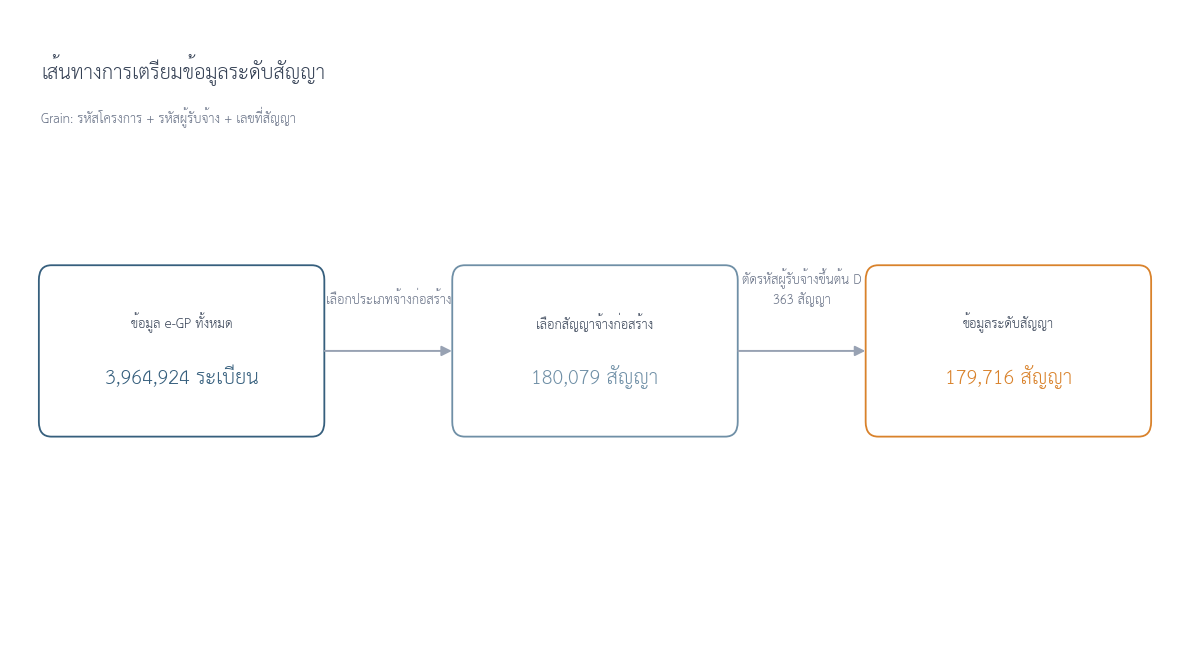

ขั้นตอน,จำนวน,หน่วย
ข้อมูล e-GP ทั้งหมด,3964924,ระเบียน
สัญญาจ้างก่อสร้าง,180079,สัญญา
ตัดรหัสผู้รับจ้างขึ้นต้น D,363,สัญญาที่ตัดออก
ข้อมูลระดับสัญญาที่ใช้วิเคราะห์,179716,สัญญา


In [6]:
check_memory('สร้างกราฟ')
source_record_count = 3964924
construction_contract_count = 180079
excluded_d_count = 363
analysis_contract_count = len(contract_data)
unique_project_count = contract_data[project_id_column].nunique()

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.set_xlim(0, 15)
ax.set_ylim(0, 7)
ax.axis('off')


def add_data_box(x, y, width, height, title, value, unit, color):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle='round,pad=0.03,rounding_size=0.16',
        linewidth=1.3,
        edgecolor=color,
        facecolor='white'
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2,
        y + height * 0.67,
        title,
        ha='center',
        va='center',
        fontsize=9,
        color=COLORS['text']
    )
    ax.text(
        x + width / 2,
        y + height * 0.34,
        f'{value:,.0f} {unit}',
        ha='center',
        va='center',
        fontsize=14,
        fontweight='semibold',
        color=color
    )


def add_data_arrow(start, end, label):
    ax.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle='-|>',
            mutation_scale=15,
            linewidth=1.4,
            color=COLORS['neutral']
        )
    )
    ax.text(
        (start[0] + end[0]) / 2,
        start[1] + 0.48,
        label,
        ha='center',
        va='bottom',
        fontsize=9,
        color=COLORS['muted']
    )


add_data_box(
    0.4, 2.4, 3.6, 1.8,
    'ข้อมูล e-GP ทั้งหมด',
    source_record_count,
    'ระเบียน',
    COLORS['primary']
)
add_data_box(
    5.7, 2.4, 3.6, 1.8,
    'เลือกสัญญาจ้างก่อสร้าง',
    construction_contract_count,
    'สัญญา',
    COLORS['secondary']
)
add_data_box(
    11.0, 2.4, 3.6, 1.8,
    'ข้อมูลระดับสัญญา',
    analysis_contract_count,
    'สัญญา',
    COLORS['highlight']
)

add_data_arrow((4.0, 3.3), (5.7, 3.3), 'เลือกประเภทจ้างก่อสร้าง')
add_data_arrow((9.3, 3.3), (11.0, 3.3), 'ตัดรหัสผู้รับจ้างขึ้นต้น D\n363 สัญญา')

ax.text(
    0.4,
    6.25,
    'เส้นทางการเตรียมข้อมูลระดับสัญญา',
    fontsize=14,
    fontweight='semibold',
    color=COLORS['text'],
    ha='left'
)
ax.text(
    0.4,
    5.78,
    'Grain: รหัสโครงการ + รหัสผู้รับจ้าง + เลขที่สัญญา',
    fontsize=9,
    color=COLORS['muted'],
    ha='left'
)

fig.tight_layout()
save_figure(fig, 'fig05_01_data_cleaning_journey')
plt.show()
plt.close(fig)

data_journey = pd.DataFrame({
    'ขั้นตอน': [
        'ข้อมูล e-GP ทั้งหมด',
        'สัญญาจ้างก่อสร้าง',
        'ตัดรหัสผู้รับจ้างขึ้นต้น D',
        'ข้อมูลระดับสัญญาที่ใช้วิเคราะห์'
    ],
    'จำนวน': [
        source_record_count,
        construction_contract_count,
        excluded_d_count,
        analysis_contract_count
    ],
    'หน่วย': [
        'ระเบียน',
        'สัญญา',
        'สัญญาที่ตัดออก',
        'สัญญา'
    ]
})

display_table(data_journey)


## Story 2 — เมื่อมองสัญญาก่อสร้างทั้งหมด เราพบอะไร

ก่อนกำหนดขอบเขต เรามองสัญญาก่อสร้างทั้ง 179,716 สัญญาก่อน ภาพซ้ายช่วยให้เห็นว่าสัญญากระจุกตัวอยู่ในช่วงวงเงินใด ส่วนภาพขวาช่วยตอบว่าวิธีจัดซื้อแบบใดเป็นองค์ประกอบหลัก

จุดที่สะดุดตาคือช่วง 400,000–500,000 บาทมีสัญญามากที่สุด และวิธีเฉพาะเจาะจงครองสัดส่วนหลัก ข้อสังเกตนี้เป็นเพียงเบาะแสแรก จึงต้องขยายดูบริเวณดังกล่าวต่อ


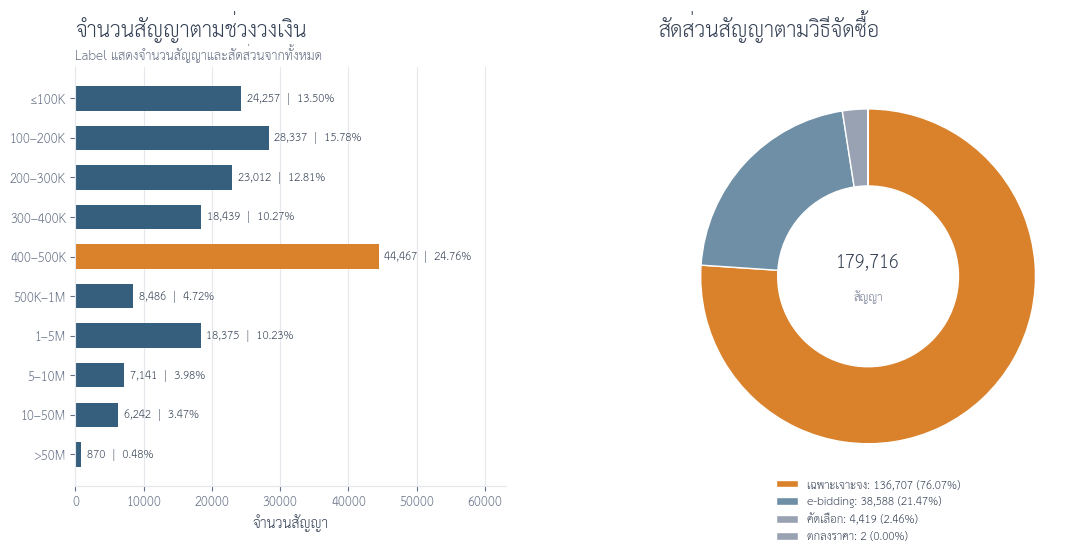

In [7]:
check_memory('สร้างกราฟ')
budget_bins = [
    -np.inf,
    100000,
    200000,
    300000,
    400000,
    500000,
    1000000,
    5000000,
    10000000,
    50000000,
    np.inf
]
budget_labels = [
    '≤100K',
    '100–200K',
    '200–300K',
    '300–400K',
    '400–500K',
    '500K–1M',
    '1–5M',
    '5–10M',
    '10–50M',
    '>50M'
]

budget_band = pd.cut(
    contract_data[contract_value_column],
    bins=budget_bins,
    labels=budget_labels,
    right=True,
    include_lowest=True
)

budget_summary = (
    budget_band
    .value_counts(sort=False)
    .rename('จำนวนสัญญา')
    .reset_index()
    .rename(columns={contract_value_column: 'ช่วงวงเงิน', 'index': 'ช่วงวงเงิน'})
)
budget_summary['สัดส่วน (%)'] = (
    budget_summary['จำนวนสัญญา'] /
    budget_summary['จำนวนสัญญา'].sum() * 100
)

method_overview = (
    contract_data[method_column]
    .fillna('ไม่ระบุ')
    .value_counts()
    .rename('จำนวนสัญญา')
    .reset_index()
    .rename(columns={'index': method_column})
)
method_overview['สัดส่วน (%)'] = (
    method_overview['จำนวนสัญญา'] /
    method_overview['จำนวนสัญญา'].sum() * 100
)
method_overview['วิธีจัดซื้อ'] = (
    method_overview[method_column]
    .replace({
        'ประกวดราคาอิเล็กทรอนิกส์ (e-bidding)': 'e-bidding'
    })
)

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
ax_budget, ax_method = axes

budget_plot = budget_summary.iloc[::-1].reset_index(drop=True)
budget_colors = [
    COLORS['highlight'] if label == '400–500K'
    else COLORS['primary']
    for label in budget_plot['ช่วงวงเงิน'].astype(str)
]
budget_bars = ax_budget.barh(
    budget_plot['ช่วงวงเงิน'].astype(str),
    budget_plot['จำนวนสัญญา'],
    color=budget_colors,
    height=0.62
)
budget_value_labels = [
    f'{count:,.0f}  |  {share:.2f}%'
    for count, share in zip(
        budget_plot['จำนวนสัญญา'],
        budget_plot['สัดส่วน (%)']
    )
]
ax_budget.bar_label(
    budget_bars,
    labels=budget_value_labels,
    padding=4,
    fontsize=8,
    color=COLORS['text']
)
ax_budget.set_title('จำนวนสัญญาตามช่วงวงเงิน', pad=22)
add_subtitle(ax_budget, 'Label แสดงจำนวนสัญญาและสัดส่วนจากทั้งหมด')
ax_budget.set_xlabel('จำนวนสัญญา')
ax_budget.set_ylabel('')
ax_budget.set_xlim(
    0,
    budget_plot['จำนวนสัญญา'].max() * 1.42
)
clean_axis(ax_budget, grid_axis='x')

method_plot = method_overview.sort_values('จำนวนสัญญา', ascending=False)
method_colors = [
    COLORS['highlight'] if method == 'เฉพาะเจาะจง'
    else COLORS['secondary'] if method == 'e-bidding'
    else COLORS['neutral']
    for method in method_plot['วิธีจัดซื้อ']
]
wedges, _ = ax_method.pie(
    method_plot['จำนวนสัญญา'],
    colors=method_colors,
    startangle=90,
    counterclock=False,
    wedgeprops={'width': 0.46, 'edgecolor': 'white'}
)
method_total = method_plot['จำนวนสัญญา'].sum()
ax_method.text(
    0,
    0.08,
    f'{method_total:,.0f}',
    ha='center',
    va='center',
    fontsize=13,
    fontweight='semibold',
    color=COLORS['text']
)
ax_method.text(
    0,
    -0.12,
    'สัญญา',
    ha='center',
    va='center',
    fontsize=8,
    color=COLORS['muted']
)
method_legend = [
    f'{method}: {count:,.0f} ({share:.2f}%)'
    for method, count, share in zip(
        method_plot['วิธีจัดซื้อ'],
        method_plot['จำนวนสัญญา'],
        method_plot['สัดส่วน (%)']
    )
]
ax_method.legend(
    wedges,
    method_legend,
    frameon=False,
    fontsize=8,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.16)
)
ax_method.set_title('สัดส่วนสัญญาตามวิธีจัดซื้อ', pad=22)

fig.subplots_adjust(
    left=0.12,
    right=0.96,
    top=0.82,
    bottom=0.20,
    wspace=0.34
)
save_figure(fig, 'fig05_02_construction_overview')
plt.show()
plt.close(fig)


## Story 3 — เมื่อขยายดูใกล้ 500,000 บาท เราพบอะไร

หลังเห็นความหนาแน่นในช่วง 400,000–500,000 บาท เราจึงขยายเฉพาะช่วง 400,000–550,000 บาท และแยกสีตามวิธีจัดซื้อ ภาพทำให้เห็นยอดกระจุกตัวทันทีใต้ 500,000 บาทอย่างชัดเจน โดยส่วนใหญ่เป็นวิธีเฉพาะเจาะจง

สิ่งที่เห็นจากภาพนี้เป็นเหตุผลให้เราลดขอบเขตการศึกษาในขั้นถัดไป ยังไม่ใช่ข้อสรุปว่ามีความผิดปกติ


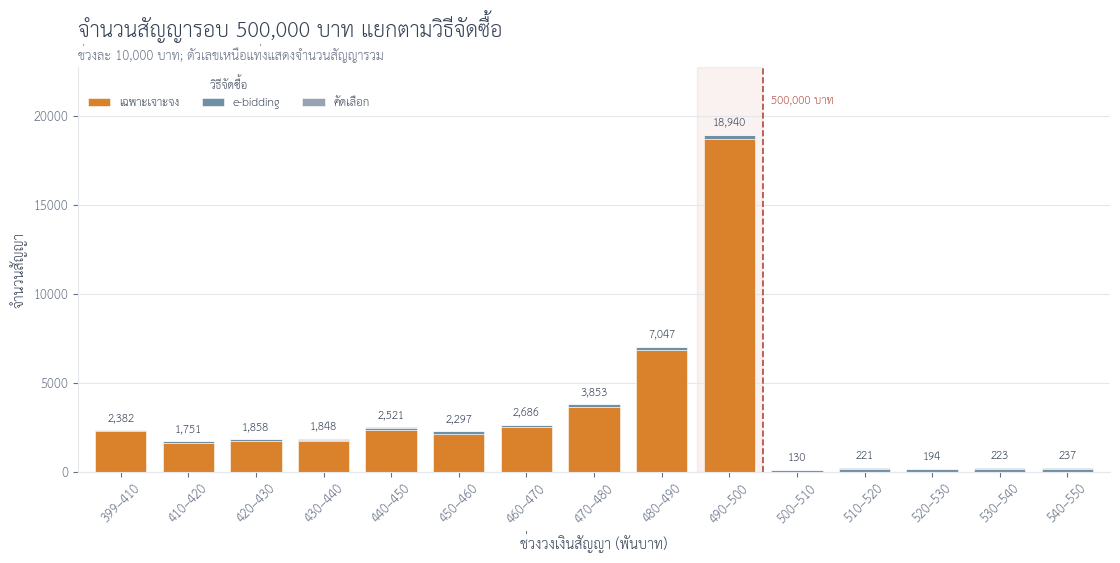

วิธีจัดซื้อ,จำนวนสัญญา,สัดส่วน (%)
เฉพาะเจาะจง,20200,98.78
e-bidding,238,1.16
คัดเลือก,12,0.06


In [8]:
check_memory('สร้างกราฟ')
focus_data = contract_data.loc[
    contract_data[contract_value_column].between(400000, 550000)
].copy()

bin_edges = np.arange(400000, 560000, 10000)
focus_data['ช่วงวงเงิน'] = pd.cut(
    focus_data[contract_value_column],
    bins=bin_edges,
    right=True,
    include_lowest=True
)

focus_data['วิธีจัดซื้อ'] = (
    focus_data[method_column]
    .fillna('ไม่ระบุ')
    .replace({
        'ประกวดราคาอิเล็กทรอนิกส์ (e-bidding)': 'e-bidding'
    })
)

stacked_summary = (
    focus_data
    .groupby(
        ['ช่วงวงเงิน', 'วิธีจัดซื้อ'],
        observed=False
    )
    .size()
    .unstack(fill_value=0)
)

method_order = (
    stacked_summary
    .sum()
    .sort_values(ascending=False)
    .index
)
stacked_summary = stacked_summary[method_order]
stacked_summary.index = [
    f'{int(interval.left / 1000):,}–{int(interval.right / 1000):,}'
    for interval in stacked_summary.index
]

stack_colors = [
    COLORS['highlight'] if method == 'เฉพาะเจาะจง'
    else COLORS['secondary'] if method == 'e-bidding'
    else COLORS['neutral']
    for method in stacked_summary.columns
]

fig, ax = plt.subplots(figsize=FIG_SIZE)

stacked_summary.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=stack_colors,
    width=0.76,
    edgecolor='white',
    linewidth=0.4
)

totals = stacked_summary.sum(axis=1)
maximum_total = totals.max()

for position, total in enumerate(totals):
    ax.text(
        position,
        total + maximum_total * 0.018,
        f'{total:,.0f}',
        ha='center',
        va='bottom',
        fontsize=8,
        color=COLORS['text']
    )

near_position = list(stacked_summary.index).index('490–500')
ax.axvspan(
    near_position - 0.48,
    near_position + 0.48,
    color=COLORS['risk'],
    alpha=0.07,
    zorder=0
)
ax.axvline(
    near_position + 0.5,
    color=COLORS['risk'],
    linewidth=1.2,
    linestyle='--'
)
ax.text(
    near_position + 0.62,
    maximum_total * 1.10,
    '500,000 บาท',
    color=COLORS['risk'],
    fontsize=8,
    va='center'
)

ax.set_title('จำนวนสัญญารอบ 500,000 บาท แยกตามวิธีจัดซื้อ', pad=22)
add_subtitle(ax, 'ช่วงละ 10,000 บาท; ตัวเลขเหนือแท่งแสดงจำนวนสัญญารวม')
ax.set_xlabel('ช่วงวงเงินสัญญา (พันบาท)')
ax.set_ylabel('จำนวนสัญญา')
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, maximum_total * 1.20)
ax.legend(
    title='วิธีจัดซื้อ',
    frameon=False,
    fontsize=8,
    title_fontsize=8,
    ncol=min(3, len(stacked_summary.columns)),
    loc='upper left'
)
clean_axis(ax, grid_axis='y')

fig.subplots_adjust(
    left=0.10,
    right=0.96,
    top=0.82,
    bottom=0.22
)
save_figure(fig, 'fig05_03_near_500k_by_method')
plt.show()
plt.close(fig)

near_method_summary = (
    focus_data.loc[
        focus_data[contract_value_column].between(490000, 500000)
    ]
    .groupby('วิธีจัดซื้อ')
    .size()
    .rename('จำนวนสัญญา')
    .reset_index()
)
near_method_summary['สัดส่วน (%)'] = (
    near_method_summary['จำนวนสัญญา'] /
    near_method_summary['จำนวนสัญญา'].sum() * 100
)
display_table(
    near_method_summary
    .sort_values('จำนวนสัญญา', ascending=False)
    .reset_index(drop=True)
)


## Story 4 — จากสิ่งที่พบ เราจึงกำหนดขอบเขตศึกษา

ขอบเขตไม่ได้ถูกตั้งไว้ล่วงหน้า แต่ค่อย ๆ ลดจากสัญญาก่อสร้างทั้งหมด 179,716 สัญญา เหลือสัญญาวงเงินไม่เกิน 500,000 บาท 138,512 สัญญา และเหลือ 136,122 สัญญาเมื่อเลือกเฉพาะวิธีเฉพาะเจาะจง

136,122 สัญญานี้คือ Study Scope สำหรับวิเคราะห์ Pattern ส่วนคำว่า “ใกล้เพดาน” ช่วง 490,000–500,000 บาทจะถูกใช้เป็นเงื่อนไขของ Pattern 1 ในขั้นถัดไป ไม่ใช่เงื่อนไขของ Scope


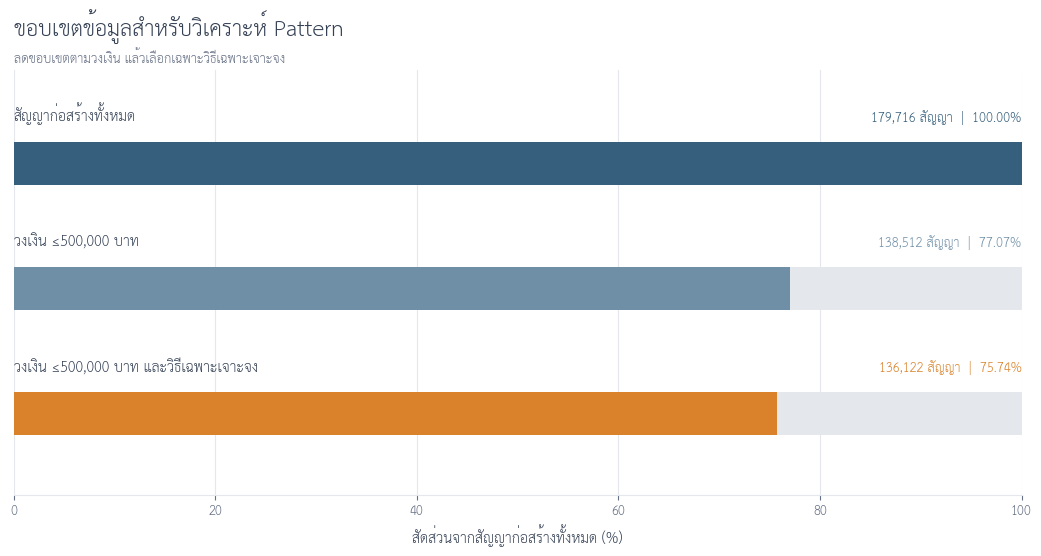

ขอบเขต,จำนวนสัญญา,สัดส่วนจากทั้งหมด (%)
สัญญาก่อสร้างทั้งหมด,179716,100.00
"วงเงิน ≤500,000 บาท",138512,77.07
"วงเงิน ≤500,000 บาท และวิธีเฉพาะเจาะจง",136122,75.74


In [9]:
check_memory('สร้างกราฟ')
under_ceiling_data = contract_data.loc[
    contract_data[contract_value_column].le(500000)
].copy()

scope_story = pd.DataFrame({
    'ขอบเขต': [
        'สัญญาก่อสร้างทั้งหมด',
        'วงเงิน ≤500,000 บาท',
        'วงเงิน ≤500,000 บาท และวิธีเฉพาะเจาะจง'
    ],
    'จำนวนสัญญา': [
        len(contract_data),
        len(under_ceiling_data),
        len(study_data)
    ],
    'สี': [
        COLORS['primary'],
        COLORS['secondary'],
        COLORS['highlight']
    ]
})

scope_story['สัดส่วนจากทั้งหมด (%)'] = (
    scope_story['จำนวนสัญญา'] /
    len(contract_data) * 100
)

plot_data = scope_story.iloc[::-1].reset_index(drop=True)
y_position = np.arange(len(plot_data))

fig, ax = plt.subplots(figsize=FIG_SIZE)

ax.barh(
    y_position,
    [100] * len(plot_data),
    color=COLORS['light'],
    height=0.34,
    edgecolor='none'
)

for y, share, count, color, label in zip(
    y_position,
    plot_data['สัดส่วนจากทั้งหมด (%)'],
    plot_data['จำนวนสัญญา'],
    plot_data['สี'],
    plot_data['ขอบเขต']
):
    ax.barh(
        y,
        share,
        color=color,
        height=0.34,
        edgecolor='none'
    )
    ax.text(
        0,
        y + 0.31,
        label,
        ha='left',
        va='bottom',
        fontsize=10,
        color=COLORS['text'],
        fontweight='semibold'
    )
    ax.text(
        100,
        y + 0.31,
        f'{count:,.0f} สัญญา  |  {share:.2f}%',
        ha='right',
        va='bottom',
        fontsize=9,
        color=color,
        fontweight='semibold'
    )

ax.set_title('ขอบเขตข้อมูลสำหรับวิเคราะห์ Pattern', pad=24)
add_subtitle(ax, 'ลดขอบเขตตามวงเงิน แล้วเลือกเฉพาะวิธีเฉพาะเจาะจง')
ax.set_xlim(0, 100)
ax.set_ylim(-0.65, len(plot_data) - 0.25)
ax.set_xlabel('สัดส่วนจากสัญญาก่อสร้างทั้งหมด (%)')
ax.set_yticks([])
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', color=COLORS['light'])
ax.grid(axis='y', visible=False)

fig.subplots_adjust(
    left=0.10,
    right=0.94,
    top=0.80,
    bottom=0.17
)
save_figure(fig, 'fig05_04_pattern_study_scope')
plt.show()
plt.close(fig)

display_table(
    scope_story[[
        'ขอบเขต',
        'จำนวนสัญญา',
        'สัดส่วนจากทั้งหมด (%)'
    ]]
)


## Story 5 — รายการใกล้เพดานเกิดซ้ำกับคู่เดิมหรือไม่

ภายใน Study Scope เราเปลี่ยนมุมมองจากสัญญาเดี่ยวเป็นคู่ **ชื่อหน่วยงาน + ผู้รับจ้าง** แล้วถามว่า คู่เดิมมีสัญญาช่วง 490,000–500,000 บาทเกิดซ้ำอย่างน้อย 3 สัญญาหรือไม่

ภาพ Top 10 จัดอันดับตามจำนวนสัญญาใกล้เพดาน เพื่อให้เห็น exposure เชิงปริมาณชัดเจน Pattern 1 พบ 9,413 สัญญาใน 1,580 คู่ แต่จำนวนที่มากยังไม่ใช่หลักฐานความผิด จึงต้องดูอีก Pattern ประกอบ


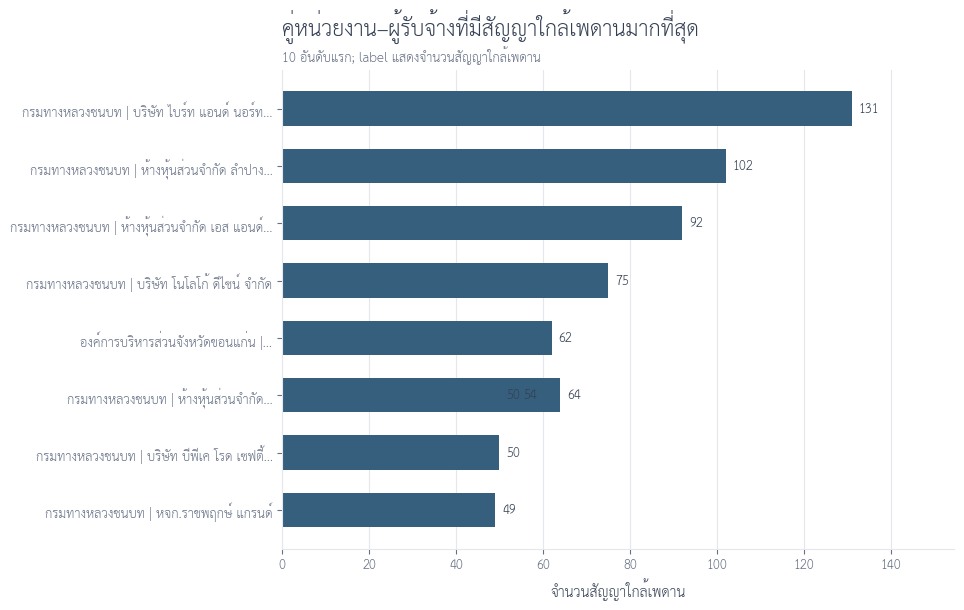

In [10]:
check_memory('สร้างกราฟ')
top_repeated_pairs = (
    repeated_pairs
    .sort_values(
        ['จำนวนสัญญาใกล้เพดาน', 'สัดส่วนจำนวนใกล้เพดาน (%)'],
        ascending=False
    )
    .head(10)
    .copy()
)

top_repeated_pairs['คู่หน่วยงาน–ผู้รับจ้าง'] = [
    shorten(
        f'{agency} | {supplier}',
        width=46,
        placeholder='…'
    )
    for agency, supplier in zip(
        top_repeated_pairs[agency_column],
        top_repeated_pairs[supplier_name_column]
    )
]

plot_data = top_repeated_pairs.iloc[::-1]

fig, ax = plt.subplots(figsize=FIG_SIZE)

bars = ax.barh(
    plot_data['คู่หน่วยงาน–ผู้รับจ้าง'],
    plot_data['จำนวนสัญญาใกล้เพดาน'],
    color=COLORS['primary'],
    height=0.60
)

ax.bar_label(
    bars,
    labels=[
        f'{count:,.0f}'
        for count in plot_data['จำนวนสัญญาใกล้เพดาน']
    ],
    padding=5,
    fontsize=9,
    color=COLORS['text']
)

ax.set_title('คู่หน่วยงาน–ผู้รับจ้างที่มีสัญญาใกล้เพดานมากที่สุด', pad=24)
add_subtitle(ax, '10 อันดับแรก; label แสดงจำนวนสัญญาใกล้เพดาน')
ax.set_xlabel('จำนวนสัญญาใกล้เพดาน')
ax.set_ylabel('')
ax.set_xlim(
    0,
    plot_data['จำนวนสัญญาใกล้เพดาน'].max() * 1.18
)
clean_axis(ax, grid_axis='x')

fig.subplots_adjust(
    left=0.40,
    right=0.96,
    top=0.83,
    bottom=0.12
)
save_figure(fig, 'fig05_05_pattern1_top10_repeated_pairs')
plt.show()
plt.close(fig)


## Story 6 — หน่วยงานพึ่งพาผู้รับจ้างรายเดิมมากเพียงใด

Pattern 2 ถามคนละคำถามกับ Pattern 1: ในหน่วยงานหนึ่ง ผู้รับจ้างรายเดิมครองทั้งจำนวนและมูลค่าสัญญาหรือไม่ เกณฑ์ที่ใช้คือคู่ต้องมีอย่างน้อย 10 สัญญา และมีสัดส่วนทั้งจำนวนสัญญาและมูลค่าตั้งแต่ 80% ขึ้นไป

ภาพจัดอันดับด้วยจำนวนสัญญา เพราะหลายคู่มีสัดส่วน 100% จนเปอร์เซ็นต์แยกความแตกต่างได้ไม่ดี Pattern 2 พบ 1,343 สัญญาใน 79 คู่


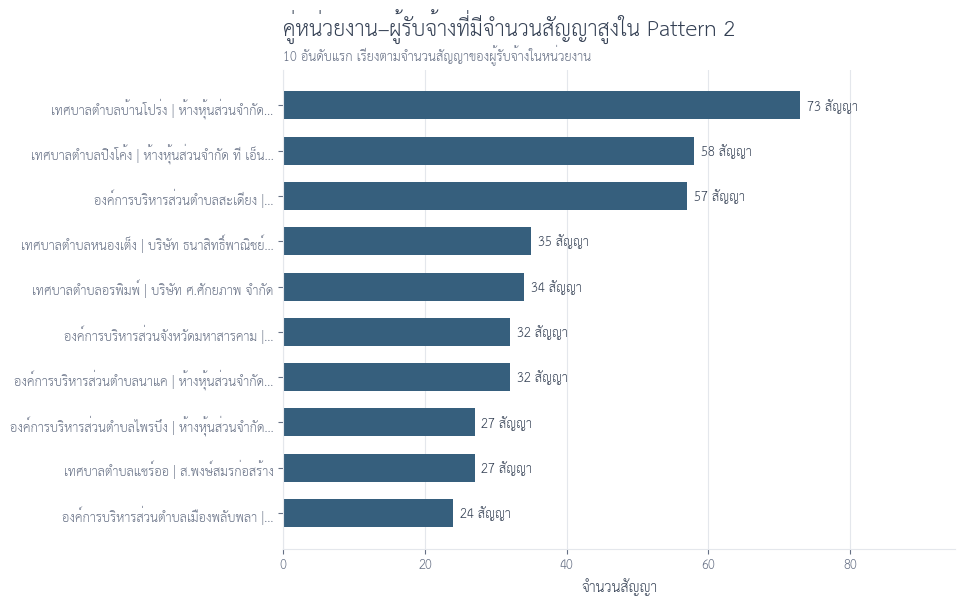

ชื่อหน่วยงาน,ผู้รับจ้าง,จำนวนสัญญา,มูลค่าสัญญารวม (บาท)
เทศบาลตำบลบ้านโปร่ง,ห้างหุ้นส่วนจำกัด สมจินตนาวงษ์เจริญ คอนกรีต,73,"7,974,800.00"
เทศบาลตำบลปิงโค้ง,ห้างหุ้นส่วนจำกัด ที เอ็น ดับเบิ้ลยู เชียงดาวก่อสร้าง,58,"13,369,200.00"
องค์การบริหารส่วนตำบลสะเดียง,ห้างหุ้นส่วนจำกัด ปุณณวุฒิก่อสร้าง,57,"17,924,800.00"
เทศบาลตำบลหนองเต็ง,บริษัท ธนาสิทธิ์พาณิชย์ จำกัด,35,"12,051,000.00"
เทศบาลตำบลอรพิมพ์,บริษัท ศ.ศักยภาพ จำกัด,34,"7,458,000.00"
องค์การบริหารส่วนจังหวัดมหาสารคาม,ห้างหุ้นส่วนจำกัด เจริญทรัพย์มหาสารคาม ก่อสร้าง,32,"15,837,000.00"
องค์การบริหารส่วนตำบลนาแค,ห้างหุ้นส่วนจำกัด จิระ 888 คอนสตรัคชั่น,32,"4,161,200.00"
องค์การบริหารส่วนตำบลไพรบึง,ห้างหุ้นส่วนจำกัด ไพรบึงทวีทรัพย์,27,"8,263,900.00"
เทศบาลตำบลแซร์ออ,ส.พงษ์สมรก่อสร้าง,27,"7,000,000.00"
องค์การบริหารส่วนตำบลเมืองพลับพลา,ห้างหุ้นส่วนจำกัด เอสพี 1971,24,"9,490,000.00"


In [11]:
check_memory('สร้างกราฟ')
top_dependency_pairs = (
    pattern2_pairs
    .sort_values(
        [
            'จำนวนรายการของผู้รับจ้าง',
            'มูลค่าของผู้รับจ้าง (บาท)'
        ],
        ascending=False
    )
    .head(10)
    .copy()
)

top_dependency_pairs['คู่หน่วยงาน–ผู้รับจ้าง'] = [
    shorten(
        f'{agency} | {supplier}',
        width=48,
        placeholder='…'
    )
    for agency, supplier in zip(
        top_dependency_pairs[agency_column],
        top_dependency_pairs['ผู้รับจ้าง']
    )
]

plot_data = top_dependency_pairs.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=FIG_SIZE)

bars = ax.barh(
    plot_data['คู่หน่วยงาน–ผู้รับจ้าง'],
    plot_data['จำนวนรายการของผู้รับจ้าง'],
    color=COLORS['primary'],
    height=0.62
)

ax.bar_label(
    bars,
    labels=[
        f'{count:,.0f} สัญญา'
        for count in plot_data['จำนวนรายการของผู้รับจ้าง']
    ],
    padding=5,
    fontsize=9,
    color=COLORS['text']
)

ax.set_title('คู่หน่วยงาน–ผู้รับจ้างที่มีจำนวนสัญญาสูงใน Pattern 2', pad=24)
add_subtitle(ax, '10 อันดับแรก เรียงตามจำนวนสัญญาของผู้รับจ้างในหน่วยงาน')
ax.set_xlabel('จำนวนสัญญา')
ax.set_ylabel('')
ax.set_xlim(
    0,
    plot_data['จำนวนรายการของผู้รับจ้าง'].max() * 1.30
)
clean_axis(ax, grid_axis='x')

fig.subplots_adjust(left=0.40, right=0.96, top=0.83, bottom=0.12)
save_figure(fig, 'fig05_06_pattern2_top10_contract_count')
plt.show()
plt.close(fig)

pattern2_table = (
    top_dependency_pairs[[
        agency_column,
        'ผู้รับจ้าง',
        'จำนวนรายการของผู้รับจ้าง',
        'มูลค่าของผู้รับจ้าง (บาท)'
    ]]
    .rename(columns={
        'จำนวนรายการของผู้รับจ้าง': 'จำนวนสัญญา',
        'มูลค่าของผู้รับจ้าง (บาท)': 'มูลค่าสัญญารวม (บาท)'
    })
)

display_table(pattern2_table)


## Story 7 — สอง Pattern มาบรรจบกันตรงไหน

ภาพนี้พาเราย้อนเส้นทางตั้งแต่สัญญาก่อสร้างทั้งหมด 179,716 สัญญา ไปยัง Study Scope 136,122 สัญญา จากนั้นจึงแยกวิเคราะห์ Pattern 1 และ Pattern 2 เป็นสองทางคู่ขนาน

เมื่อเลือกเฉพาะสัญญาที่เข้าเงื่อนไขทั้งสองพร้อมกัน เหลือ 161 สัญญา จุดตัดนี้ช่วยลดภาระการตรวจเอกสาร แต่ไม่ได้แปลว่าสัญญาทั้ง 161 รายการมีการทุจริต


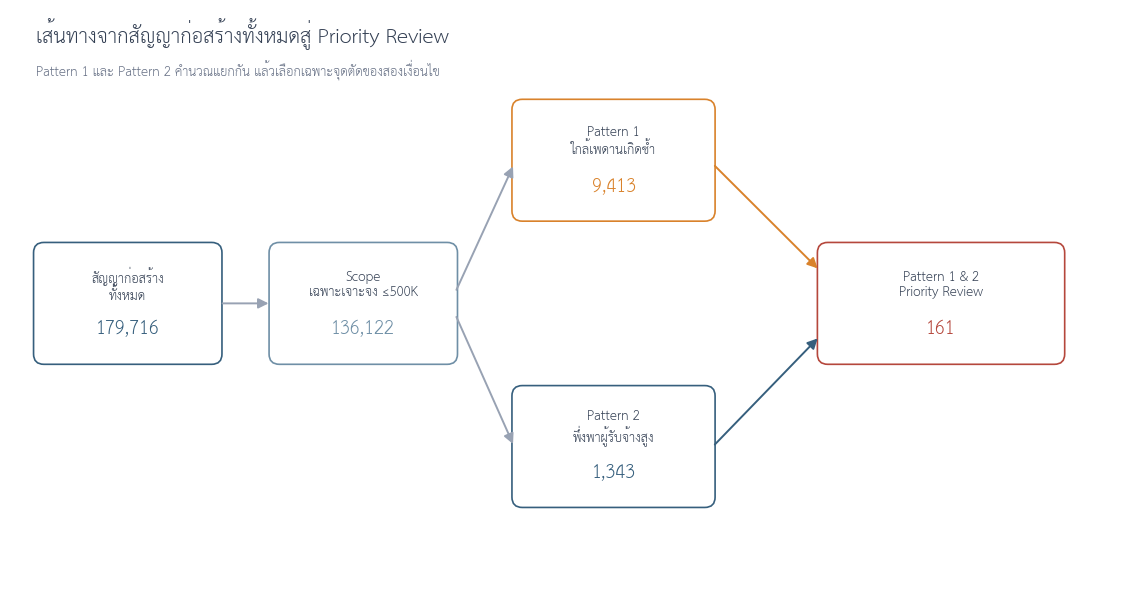

In [12]:
check_memory('สร้างกราฟ')
all_contract_count = len(contract_data)
study_count = len(study_data)
pattern1_count = int(contract_flags['flag_pattern_1'].sum())
pattern2_count = int(contract_flags['flag_pattern_2'].sum())
priority_count = int(contract_flags['priority_review'].sum())

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.set_xlim(0, 15)
ax.set_ylim(0, 8)
ax.axis('off')


def add_recap_box(x, y, width, height, title, value, color):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle='round,pad=0.03,rounding_size=0.14',
        linewidth=1.2,
        edgecolor=color,
        facecolor='white'
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2,
        y + height * 0.66,
        title,
        ha='center',
        va='center',
        fontsize=9,
        color=COLORS['text'],
        linespacing=1.15
    )
    ax.text(
        x + width / 2,
        y + height * 0.28,
        f'{value:,.0f}',
        ha='center',
        va='center',
        fontsize=13,
        fontweight='semibold',
        color=color
    )


def add_recap_arrow(start, end, color=COLORS['neutral']):
    ax.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle='-|>',
            mutation_scale=15,
            linewidth=1.4,
            color=color,
            connectionstyle='arc3,rad=0.0'
        )
    )


add_recap_box(
    0.35, 3.2, 2.5, 1.6,
    'สัญญาก่อสร้าง\nทั้งหมด',
    all_contract_count,
    COLORS['primary']
)
add_recap_box(
    3.55, 3.2, 2.5, 1.6,
    'Scope\nเฉพาะเจาะจง ≤500K',
    study_count,
    COLORS['secondary']
)
add_recap_box(
    6.85, 5.15, 2.7, 1.6,
    'Pattern 1\nใกล้เพดานเกิดซ้ำ',
    pattern1_count,
    COLORS['highlight']
)
add_recap_box(
    6.85, 1.25, 2.7, 1.6,
    'Pattern 2\nพึ่งพาผู้รับจ้างสูง',
    pattern2_count,
    COLORS['primary']
)
add_recap_box(
    11.0, 3.2, 3.3, 1.6,
    'Pattern 1 & 2\nPriority Review',
    priority_count,
    COLORS['risk']
)

add_recap_arrow((2.85, 4.0), (3.55, 4.0))
add_recap_arrow((6.05, 4.15), (6.85, 5.90))
add_recap_arrow((6.05, 3.85), (6.85, 2.05))
add_recap_arrow((9.55, 5.90), (11.0, 4.45), COLORS['highlight'])
add_recap_arrow((9.55, 2.05), (11.0, 3.55), COLORS['primary'])

ax.text(
    0.35,
    7.55,
    'เส้นทางจากสัญญาก่อสร้างทั้งหมดสู่ Priority Review',
    fontsize=14,
    fontweight='semibold',
    color=COLORS['text'],
    ha='left'
)
ax.text(
    0.35,
    7.10,
    'Pattern 1 และ Pattern 2 คำนวณแยกกัน แล้วเลือกเฉพาะจุดตัดของสองเงื่อนไข',
    fontsize=9,
    color=COLORS['muted'],
    ha='left'
)

fig.subplots_adjust(
    left=0.04,
    right=0.96,
    top=0.92,
    bottom=0.05
)
save_figure(fig, 'fig05_07_pattern_intersection_journey')
plt.show()
plt.close(fig)


## Story 8 — ถ้าต้องเปิดเอกสาร เราควรเริ่มจากคู่ใด

161 สัญญาที่อยู่ในจุดตัดถูกสรุปกลับเป็นคู่ **ชื่อหน่วยงาน + ผู้รับจ้าง** แล้วจัดอันดับตามจำนวนสัญญา ภาพและตาราง Top 10 จึงทำหน้าที่เป็น work queue สำหรับกำหนดว่าจะเปิดเอกสารของคู่ใดก่อน

สิ่งที่ควรตรวจต่อคือ TOR ใบเสนอราคา ผู้เสนอราคารายอื่น วันที่จัดซื้อ ขอบเขตงาน และความเชื่อมโยงระหว่างสัญญา การจัดอันดับนี้ไม่ใช่การจัดอันดับความทุจริต


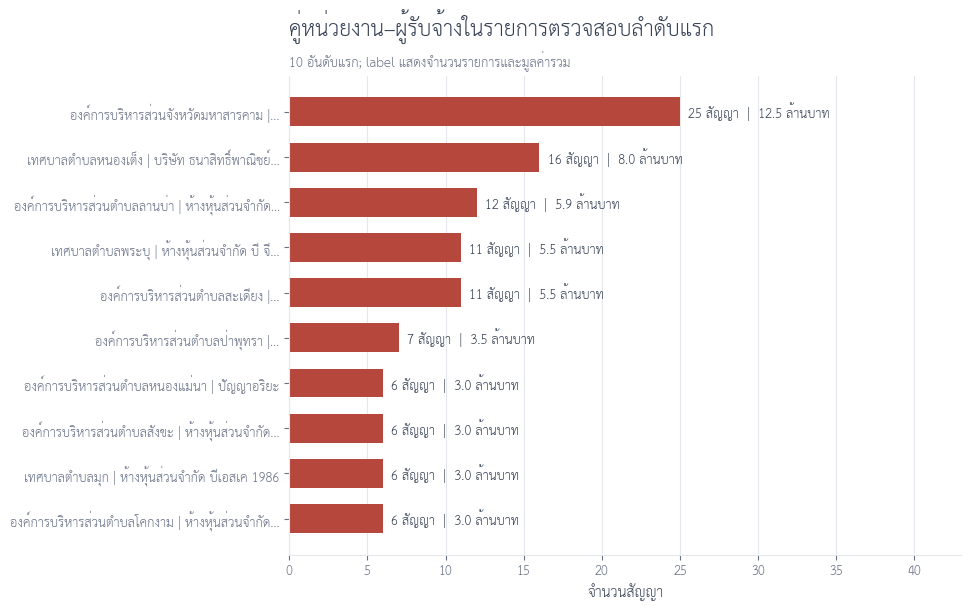

ลำดับ,ชื่อหน่วยงาน,ชื่อผู้ชนะการเสนอราคา,จังหวัด,จำนวนสัญญาตรวจสอบ,มูลค่ารวม (บาท)
1,องค์การบริหารส่วนจังหวัดมหาสารคาม,ห้างหุ้นส่วนจำกัด เจริญทรัพย์มหาสารคาม ก่อสร้าง,มหาสารคาม,25,"12,454,000.00"
2,เทศบาลตำบลหนองเต็ง,บริษัท ธนาสิทธิ์พาณิชย์ จำกัด,บุรีรัมย์,16,"7,952,000.00"
3,องค์การบริหารส่วนตำบลลานบ่า,ห้างหุ้นส่วนจำกัด ลานบ่า คอนสตรัคชั่น,เพชรบูรณ์,12,"5,914,000.00"
4,เทศบาลตำบลพระบุ,ห้างหุ้นส่วนจำกัด บี จี วิศวกรรม แอนด์ คอนสตรัคชั่น,ขอนแก่น,11,"5,475,400.00"
5,องค์การบริหารส่วนตำบลสะเดียง,ห้างหุ้นส่วนจำกัด ปุณณวุฒิก่อสร้าง,เพชรบูรณ์,11,"5,454,000.00"
6,องค์การบริหารส่วนตำบลป่าพุทรา,ห้างหุ้นส่วนจำกัด รวมญาติแทรคเตอร์,กำแพงเพชร,7,"3,465,500.00"
7,องค์การบริหารส่วนตำบลหนองแม่นา,ปัญญาอริยะ,เพชรบูรณ์,6,"2,997,000.00"
8,องค์การบริหารส่วนตำบลสังขะ,ห้างหุ้นส่วนจำกัด รวมชัยสังขะ,สุรินทร์,6,"2,982,400.00"
9,เทศบาลตำบลมุก,ห้างหุ้นส่วนจำกัด บีเอสเค 1986,มุกดาหาร,6,"2,969,200.00"
10,องค์การบริหารส่วนตำบลโคกงาม,ห้างหุ้นส่วนจำกัด เบ๊นซ์วัสดุก่อสร้าง,เลย,6,"2,962,000.00"


In [13]:
check_memory('สร้างกราฟ')
priority_pair_summary = (
    priority_contracts
    .groupby(
        [agency_column, supplier_id_column],
        dropna=False
    )
    .agg({
        supplier_name_column: 'first',
        province_column: 'first',
        contract_column: 'size',
        contract_value_column: 'sum'
    })
    .reset_index()
    .rename(columns={
        contract_column: 'จำนวนสัญญาตรวจสอบ',
        contract_value_column: 'มูลค่ารวม (บาท)'
    })
    .sort_values(
        ['จำนวนสัญญาตรวจสอบ', 'มูลค่ารวม (บาท)'],
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

priority_pair_summary.insert(
    0,
    'ลำดับ',
    np.arange(1, len(priority_pair_summary) + 1)
)

priority_pair_summary['คู่หน่วยงาน–ผู้รับจ้าง'] = [
    shorten(
        f'{agency} | {supplier}',
        width=48,
        placeholder='…'
    )
    for agency, supplier in zip(
        priority_pair_summary[agency_column],
        priority_pair_summary[supplier_name_column]
    )
]

plot_data = priority_pair_summary.iloc[::-1]

fig, ax = plt.subplots(figsize=FIG_SIZE)

bars = ax.barh(
    plot_data['คู่หน่วยงาน–ผู้รับจ้าง'],
    plot_data['จำนวนสัญญาตรวจสอบ'],
    color=COLORS['risk'],
    height=0.64
)

labels = [
    f'{count:,.0f} สัญญา  |  {value / 1_000_000:,.1f} ล้านบาท'
    for count, value in zip(
        plot_data['จำนวนสัญญาตรวจสอบ'],
        plot_data['มูลค่ารวม (บาท)']
    )
]

ax.bar_label(
    bars,
    labels=labels,
    padding=6,
    fontsize=9,
    color=COLORS['text']
)

ax.set_title('คู่หน่วยงาน–ผู้รับจ้างในรายการตรวจสอบลำดับแรก', pad=28)
add_subtitle(ax, '10 อันดับแรก; label แสดงจำนวนรายการและมูลค่ารวม')
ax.set_xlabel('จำนวนสัญญา')
ax.set_ylabel('')
ax.set_xlim(0, plot_data['จำนวนสัญญาตรวจสอบ'].max() * 1.72)
clean_axis(ax, grid_axis='x')

fig.subplots_adjust(left=0.40, right=0.96, top=0.83, bottom=0.12)
save_figure(fig, 'fig05_08_priority_top10_pairs')
plt.show()
plt.close(fig)

priority_table = priority_pair_summary[[
    'ลำดับ',
    agency_column,
    supplier_name_column,
    province_column,
    'จำนวนสัญญาตรวจสอบ',
    'มูลค่ารวม (บาท)'
]].copy()

display_table(priority_table)


## สรุปลำดับการเล่าจากภาพ

| ลำดับ | ภาพ | ประโยคหลักสำหรับนำเสนอ |
|---:|---|---|
| 1 | `fig05_01_data_cleaning_journey` | เราเริ่มจาก 3.96 ล้านระเบียน และเตรียมจนเหลือ 179,716 สัญญา |
| 2 | `fig05_02_construction_overview` | เมื่อมองทั้งหมด ช่วง 400,000–500,000 บาทและวิธีเฉพาะเจาะจงเด่นขึ้นมา |
| 3 | `fig05_03_near_500k_by_method` | เมื่อขยายดู จึงเห็นการกระจุกตัวทันทีใต้ 500,000 บาท |
| 4 | `fig05_04_pattern_study_scope` | สิ่งที่พบพาเราไปสู่ Study Scope 136,122 สัญญา |
| 5 | `fig05_05_pattern1_top10_repeated_pairs` | Pattern 1 มองการเกิดสัญญาใกล้เพดานซ้ำกับคู่เดิม |
| 6 | `fig05_06_pattern2_top10_contract_count` | Pattern 2 มองการพึ่งพาผู้รับจ้างรายเดิมภายในหน่วยงาน |
| 7 | `fig05_07_pattern_intersection_journey` | จุดตัดของสอง Pattern ลดงานตรวจเหลือ 161 สัญญา |
| 8 | `fig05_08_priority_top10_pairs` | Top 10 ช่วยบอกว่าควรเปิดเอกสารของคู่ใดก่อน |

ภาพทั้งหมดใช้ขนาด 1,440 × 810 pixels เพื่อให้แสดงผลสม่ำเสมอบน GitHub


In [14]:
# ลบเฉพาะไฟล์พักและปิดรูปที่ Notebook นี้สร้าง; เก็บ DataFrame ไว้ดูผลต่อ
cleanup_runtime()


ปิดรูปและลบไฟล์พักของ Notebook แล้ว; DataFrame ผลวิเคราะห์ยังอยู่ใน RAM
